## Machine Learning Course Project - Phase III
### Name: R.Bhargavsai
### PRN: 230200033
### Dataset: Electrical Grid Stability
### Task: Classification
### Target Variable: stadf

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

## 2. Load and Preprocess Data

In [ ]:
df = pd.read_csv('/content/Data_for_UCI_named.csv')

# Encode target variable
le = LabelEncoder()
y = le.fit_transform(df['stabf'])
X = df.drop('stabf', axis=1)

# Split data (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define preprocessors for SVM and tree-based models (from Phase II)
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Preprocessor for SVM (scaling + encoding)
svm_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Preprocessor for tree-based models (only encoding)
tree_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

# Transform data
X_train_svm = svm_preprocessor.fit_transform(X_train)
X_test_svm = svm_preprocessor.transform(X_test)

X_train_tree = tree_preprocessor.fit_transform(X_train)
X_test_tree = tree_preprocessor.transform(X_test)

## 3. Hyperparameter Tuning
## 3.1 SVM with RBF Kernel

In [ ]:
# Step 1: Randomized Search (coarse)
param_dist_svm = {
    'C': np.logspace(-3, 3, 100),
    'gamma': np.logspace(-3, 3, 100)
}

svm_rbf = SVC(kernel='rbf', random_state=42)
random_search_svm = RandomizedSearchCV(
    svm_rbf, param_dist_svm, n_iter=50, cv=5, scoring='accuracy', n_jobs=-1
)
random_search_svm.fit(X_train_svm, y_train)

# Step 2: Grid Search (fine-tuned range)
best_C = random_search_svm.best_params_['C']
best_gamma = random_search_svm.best_params_['gamma']

param_grid_svm = {
    'C': np.linspace(best_C/2, best_C*2, 10),
    'gamma': np.linspace(best_gamma/2, best_gamma*2, 10)
}

grid_search_svm = GridSearchCV(
    svm_rbf, param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1
)
grid_search_svm.fit(X_train_svm, y_train)

# Best model
best_svm = grid_search_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test_svm)
print("Best SVM (RBF) Parameters:", grid_search_svm.best_params_)
print("Test Accuracy:", accuracy_score(y_test, y_pred_svm))

Best SVM (RBF) Parameters: {'C': np.float64(1304.623503926675), 'gamma': np.float64(0.0010132740553019555)}
Test Accuracy: 0.9965


## 3.2 Random Forest

In [ ]:
# Step 1: Randomized Search
param_dist_rf = {
    'n_estimators': np.arange(50, 500, 50),
    'max_depth': np.arange(2, 20, 2)
}

rf = RandomForestClassifier(random_state=42)
random_search_rf = RandomizedSearchCV(
    rf, param_dist_rf, n_iter=20, cv=5, scoring='accuracy', n_jobs=-1
)
random_search_rf.fit(X_train_tree, y_train)

# Step 2: Grid Search
best_n_estimators = random_search_rf.best_params_['n_estimators']
best_max_depth = random_search_rf.best_params_['max_depth']

param_grid_rf = {
    'n_estimators': np.arange(best_n_estimators-25, best_n_estimators+25, 10),
    'max_depth': np.arange(best_max_depth-2, best_max_depth+2, 1)
}

grid_search_rf = GridSearchCV(
    rf, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1
)
grid_search_rf.fit(X_train_tree, y_train)

# Best model
best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_tree)
print("Best RF Parameters:", grid_search_rf.best_params_)
print("Test Accuracy:", accuracy_score(y_test, y_pred_rf))

Best RF Parameters: {'max_depth': np.int64(4), 'n_estimators': np.int64(425)}
Test Accuracy: 1.0


## 3.3 AdaBoost with Decision Tree Stumps

In [ ]:
# Base estimator (decision tree stump)
from sklearn.tree import DecisionTreeClassifier
base_tree = DecisionTreeClassifier(max_depth=1, random_state=42)

# Step 1: Randomized Search
param_dist_ada = {
    'n_estimators': np.arange(50, 500, 50),
    'learning_rate': np.logspace(-3, 0, 100)
}

ada = AdaBoostClassifier(estimator=base_tree, random_state=42)
random_search_ada = RandomizedSearchCV(
    ada, param_dist_ada, n_iter=20, cv=5, scoring='accuracy', n_jobs=-1
)
random_search_ada.fit(X_train_tree, y_train)

# Step 2: Grid Search
best_n_estimators_ada = random_search_ada.best_params_['n_estimators']
best_lr_ada = random_search_ada.best_params_['learning_rate']

param_grid_ada = {
    'n_estimators': np.arange(best_n_estimators_ada-25, best_n_estimators_ada+25, 10),
    'learning_rate': np.linspace(best_lr_ada/2, best_lr_ada*2, 10)
}

grid_search_ada = GridSearchCV(
    ada, param_grid_ada, cv=5, scoring='accuracy', n_jobs=-1
)
grid_search_ada.fit(X_train_tree, y_train)

# Best model
best_ada = grid_search_ada.best_estimator_
y_pred_ada = best_ada.predict(X_test_tree)
print("Best AdaBoost Parameters:", grid_search_ada.best_params_)
print("Test Accuracy:", accuracy_score(y_test, y_pred_ada))

Best AdaBoost Parameters: {'learning_rate': np.float64(0.0009369087114301915), 'n_estimators': np.int64(25)}
Test Accuracy: 1.0


## 3.4 Gradient Boosting

In [ ]:
# Step 1: Randomized Search
param_dist_gb = {
    'n_estimators': np.arange(50, 500, 50),
    'max_depth': np.arange(2, 10, 1)
}

gb = GradientBoostingClassifier(random_state=42)
random_search_gb = RandomizedSearchCV(
    gb, param_dist_gb, n_iter=20, cv=5, scoring='accuracy', n_jobs=-1
)
random_search_gb.fit(X_train_tree, y_train)

# Step 2: Grid Search
best_n_estimators_gb = random_search_gb.best_params_['n_estimators']
best_max_depth_gb = random_search_gb.best_params_['max_depth']

param_grid_gb = {
    'n_estimators': np.arange(best_n_estimators_gb-25, best_n_estimators_gb+25, 10),
    'max_depth': np.arange(best_max_depth_gb-1, best_max_depth_gb+1, 1)
}

grid_search_gb = GridSearchCV(
    gb, param_grid_gb, cv=5, scoring='accuracy', n_jobs=-1
)
grid_search_gb.fit(X_train_tree, y_train)

# Best model
best_gb = grid_search_gb.best_estimator_
y_pred_gb = best_gb.predict(X_test_tree)
print("Best GB Parameters:", grid_search_gb.best_params_)
print("Test Accuracy:", accuracy_score(y_test, y_pred_gb))

Best GB Parameters: {'max_depth': np.int64(4), 'n_estimators': np.int64(125)}
Test Accuracy: 1.0


## 4. Performance Comparison

<ipython-input-18-5dfdf14f5f88>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')


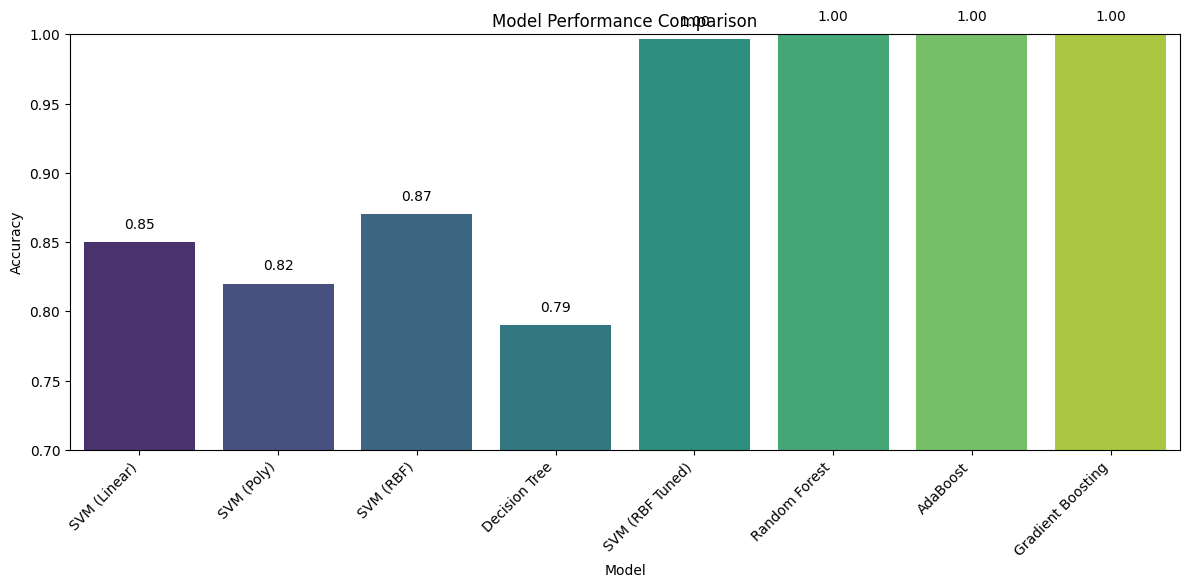

In [ ]:
baseline_results = {
    'Model': ['SVM (Linear)', 'SVM (Poly)', 'SVM (RBF)', 'Decision Tree'],
    'Accuracy': [0.85, 0.82, 0.87, 0.79]
}
df_base = pd.DataFrame(baseline_results)

# 2) Phase III tuned models
phase3_results = {
    'Model': ['SVM (RBF Tuned)', 'Random Forest', 'AdaBoost', 'Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_ada),
        accuracy_score(y_test, y_pred_gb)
    ]
}
df_phase3 = pd.DataFrame(phase3_results)

# 3) Combine
results_df = pd.concat([df_base, df_phase3], ignore_index=True)

# 4) Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
plt.title('Model Performance Comparison')
plt.ylim(0.7, 1.0)
plt.xticks(rotation=45, ha='right')
for idx, acc in enumerate(results_df['Accuracy']):
    plt.text(idx, acc + 0.01, f"{acc:.2f}", ha='center')
plt.tight_layout()
plt.show()